# Validation and Cross Validation

In data science and chemometrics, model evaluation is a critical step in understanding how well a model performs. Depending on the model type there are several different approaches for the validation and cross validation. These measures are usually a combination of model performance and testing using external data. The following metrics are commonly used for such assessments: 

1. Confusion matrix,
2. Performance metrics (sensitivity, specificity, precision, etc.),
3. Receiver Operating Characteristic (ROC) curves and threshold optimization,
4. Cross-validation techniques, including k-fold CV.

## Confusion Matrix

A confusion matrix is a summary of prediction results on a classification problem.
It shows the number of correct and incorrect predictions made by the model compared to the actual outcomes (ground truth).

|                | Predicted Positive | Predicted Negative |
|----------------|--------------------|--------------------|
| Actual Positive| True Positive (TP) | False Negative (FN)|
| Actual Negative| False Positive (FP)| True Negative (TN) |

### E1: 

Let's come up with practical examples for each on these cases.

- **True Positive (TP)**: A person with COVID correctly tested positive.
- **True Negative (TN)**: A person without COVID correctly tested negative.
- **False Positive (FP)**: A person without COVID incorrectly tested positive.
- **False Negative (FN)**: A person with COVID incorrectly tested negative.

## Performance Metrics: 

Using the confusion matrix, we can calculate several performance metrics:

### **True Positive Rate (TPR)** 

TPR or Sensitivity, Recall: is the ratio of TPs that have been correctly identified by the model. 

```math 

TPR = \frac{TP}{P} = \frac{TP}{(TP + FN)}


```

### E2: 

There is a new Covid variant and we want to assess whether our self-tests are good enough. We take 100 tests and distribute them amongst two groups of 50 each- first with covid and second without covid. 20 people with covid test negative and 48 people without covid test negative.

In [13]:
using ACS 

TPR = 30 / 50 

0.6

### **False Negative Rate (FNR)**:

FNR or Miss Rate is the ratio of positive cases missed by the model (i.e. FN) and all positives.

```math 

FNR = \frac{FN}{P} = \frac{FN}{(TP + FN)}

```

### E3: 

Let's calculate the FNR for the above case. 

In [14]:
FNR = 20 / 50

0.4

### **False Positive Rate (FPR)**:

FPR or Fall-out is the rate of incorrect positive predictions and is the ratio of FP and all negatives. 

```math 

FPR = \frac{FP}{N} = \frac{FP}{TN + FP}

```

### E4: 

Let's calculate the FPR for our COVID test. 

In [15]:
FPR = 2 / (48 + 2)

0.04

### **True Negative Rate (TNR)**:

TNR or selectivity, specificity is the rate of correct negative predictions. TNR is the ratio of the correct negative predictions and all negatives.

```math 

TNR = \frac{TN}{N} = \frac{TN}{TN + FP}

```


### E5: 

Let's calculate the TNR of our testing system. 

In [16]:
TNR = 48 / (48 + 2)

0.96

### **Positive Prediction Values (PPV)**:

PPV or the model precision is the rate of correct positive predictions and calculated as the ratio of TP and model's positive predictions. 

```math 

PPV = \frac{TP}{PP} = \frac{TP}{TP + FP}

```

### E6: 

Let's calculate the PPV for our test.

In [17]:
PPV = 30 / (30 + 2)

0.9375

### **False Discovery Rate (FDR)**:

FDR is the rate of incorrect positive predictions among all the positive predictions and calculated using the following equation: 

```math 

FDR = \frac{FP}{PP} = \frac{FP}{TP + FP}


```

### E7: 

What is the FDR of our test? 

In [18]:
FDR = 2 / (30 + 2)

0.0625

### E8: 

What is the difference between the FDR and FPR? 

> Answer to E8: 
>
> The FPR tells you that 0.04 of people who did not have the disease were identified as having the disease. The FDR tells you that 0.063 of people who were identified as having the disease actually did not have the disease.
> 

<div class="alert alert-block alert-warning">
<b>Tip:</b> In many real-life cases you cannot calculate the FPR as you do not have a way to estimate the true number of TNs. In those situations, FDR can be very helpful in giving you some insights into a model performance.  
</div>

### **False Omission Rate (FOR)**:

FOR is the rate of incorrect negative predictions among the total negative predictions. 

```math 

FOR = \frac{FN}{PN} = \frac{FN}{TN + FN}


```

### E9: 

Please calculate the FOR for the COVID test. 

In [19]:
FOR = 20 / (20 + 48)

0.29411764705882354

### **Negative Predictive Value (NPV)**:

NPV is the rate of correct negative predictions among the total negative predictions. 

```math 

NPV = \frac{TN}{PN} = \frac{TN}{TN + FN}


```


### E10: 

Let's calculate the NPV for our test.

In [20]:
NPV = 48 / (20 + 48)

0.7058823529411765

### E11: 

Have you noticed any trends in your results? 

> Answer to E11: 
>
> There is a bit of redundancy in these metrics as each pair (e.g. TPR and FNR) sum up to 1. In other words, calculating one of them will give you access to the second one. 
> 

### E12: 

Let's write a function that generates the full confusion matrix given the TP, FN, FP, and TN values. 

## ROC Curves and Threshold Setting: 

The ROC (Receiver Operating Characteristic) curve plots the TPR vs. FPR across different decision thresholds.
It allows us to visually inspect the trade-off between sensitivity and specificity, and is widely used to compare classifier performance, model comparison, and hyperparameter optimization.

The area under the ROC curve (AUC) provides a single-number summary of the performance — a value of 1 means perfect classification.

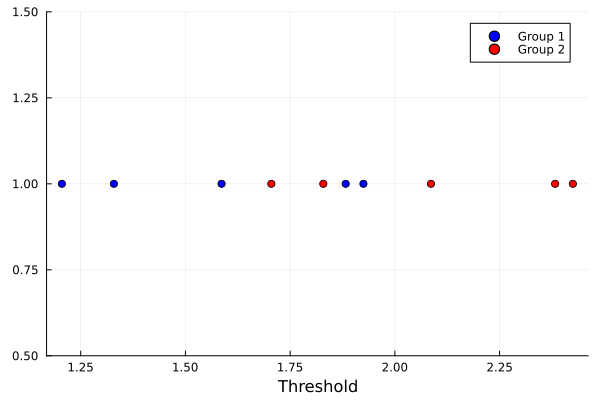

In [21]:
n = rand(5)
g1 = n .+ 1
g2 = n .+ 1.5

scatter(g1,ones(5), label="Group 1", color=:blue)
scatter!(g2, ones(5), label="Group 2", color=:red)
ylims!(0.5, 1.5)
xlabel!("Threshold")

For us to be able to systematically assess the optimum threshold we can calculate the FPR vs TPR for a range of thresholds.  

### E13: 

How would it look if we set our threshold to 1.2?

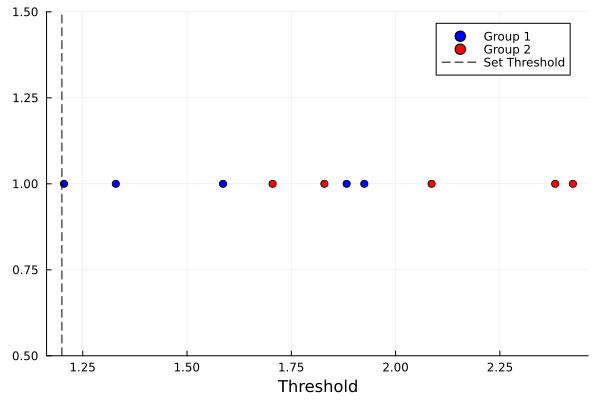

In [22]:
scatter(g1,ones(5), label="Group 1", color=:blue)
scatter!(g2, ones(5), label="Group 2", color=:red)
plot!([1.2, 1.2], [0.5, 1.5], label="Set Threshold", color=:black, linestyle=:dash)
ylims!(0.5, 1.5)
xlabel!("Threshold")

Given that all the data points are on the left of the set threshold, we are essentially putting all data points into group 2.  

In [23]:
FPR_g1 = 0 / (5 + 0)
TPR_g1 = 0 / (5 + 0)

FPR_g2 = 5 / (5 + 0)
TPR_g2 = 5 / (5 + 0)

println("FPR Group 1: ", FPR_g1)
println("TPR Group 1: ", TPR_g1)
println("FPR Group 2: ", FPR_g2)
println("TPR Group 2: ", TPR_g2)

FPR Group 1: 0.0
TPR Group 1: 0.0
FPR Group 2: 1.0
TPR Group 2: 1.0


### E14: 

What if we move the threshold to 1.4?

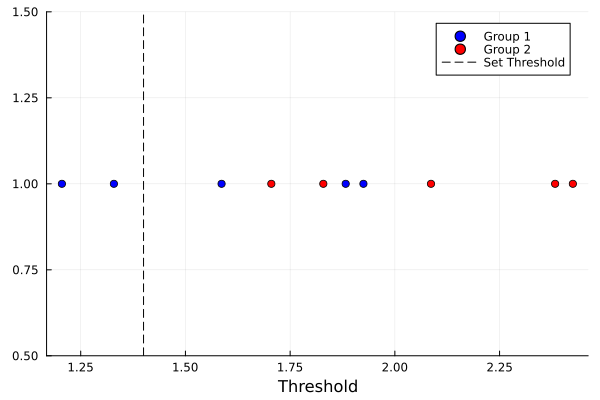

In [24]:
scatter(g1,ones(5), label="Group 1", color=:blue)
scatter!(g2, ones(5), label="Group 2", color=:red)
plot!([1.4, 1.4], [0.5, 1.5], label="Set Threshold", color=:black, linestyle=:dash)
ylims!(0.5, 1.5)
xlabel!("Threshold")

Now we have two TP cases for G1 and no FP for that group while having three FN for it. 

In [25]:
FPR_g1 = 0 / (0 + 5)
TPR_g1 = 2 / (2 + 3)

FPR_g2 = 3 / (3 + 3)
TPR_g2 = 5 / (5 + 0)

println("FPR Group 1: ", FPR_g1)
println("TPR Group 1: ", TPR_g1)
println("FPR Group 2: ", FPR_g2)
println("TPR Group 2: ", TPR_g2)

FPR Group 1: 0.0
TPR Group 1: 0.4
FPR Group 2: 0.5
TPR Group 2: 1.0


### E15: 

Let's write a loop to calculate these rates for different threshold.

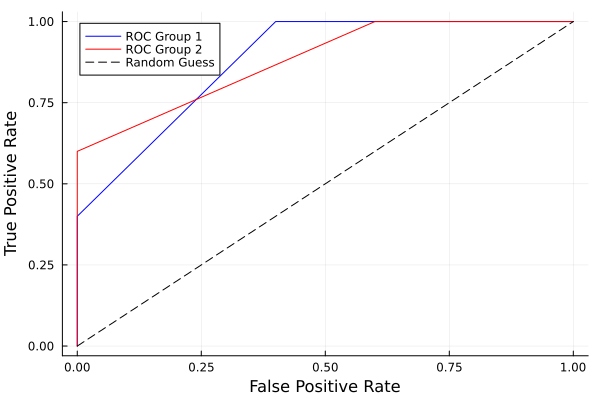

In [26]:
tr = 1:0.5:3
tpr1 = zeros(length(tr))
fpr1 = zeros(length(tr))
tpr2 = zeros(length(tr))
fpr2 = zeros(length(tr))

for i = 1:length(tr)
    tp_g1 = length(g1[g1 .<= tr[i]])
    fp_g2 = length(g1[g1 .> tr[i]])
    tp_g2 = length(g2[g2 .>= tr[i]])    
    fp_g1 = length(g2[g2 .< tr[i]])
    tpr1[i] = tp_g1 / (tp_g1 + fp_g2)
    fpr1[i] = fp_g1 / (fp_g1 + tp_g2)
    tpr2[i] = tp_g2 / (tp_g2 + fp_g1)
    fpr2[i] = fp_g2 / (fp_g2 + tp_g1)
end

plot(fpr1, tpr1, label="ROC Group 1", color=:blue)
plot!(fpr2, tpr2, label="ROC Group 2", color=:red)
plot!([0, 1], [0, 1], label="Random Guess", color=:black, linestyle=:dash)
xlabel!("False Positive Rate")
ylabel!("True Positive Rate")

Using ROC curves one can easily decide the best ratio of TPR vs FPR. The ROC curves are one of the most objective approaches to model optimization.

## K-Fold Cross Validation (CV):

When building a model, you will have to divide your data into training and test sets. Training set is a part of data that model is using for learning the underlying trends in your data while the test set is used for final evaluation of the model performance. It should be noted that during this process we want to make sure that the data in the test set is not seen by the model during the training (i.e. [data leakage](https://en.wikipedia.org/wiki/Leakage_(machine_learning))). However, before the assessment of the final model we will need to optimize its hyperparameters. For this we can use the k-fold cross-validation. 

Cross-validation is a technique to evaluate models by training them on subsets of data and testing them on complementary subsets. K-fold cross-validation divides the data into 'k' parts (folds). Each fold is used once as a test set while the remaining k-1 folds form the training set. This helps reduce [overfitting](https://en.wikipedia.org/wiki/Overfitting) and provides a better estimate of model performance on unseen data.

<div class="alert alert-block alert-warning">
<b>Tip:</b> Please note that this method assumes that your data is homogeneously distributed and random sampling of a subset of the data does not have a significant impact on the model performance. If you see such effects, you will need to do the sampling of k-folds after stratification of your data.  
</div>

### How?

To perform k-fold CV, you divide your training set to k randomly selected equal size chunks (e.g. 3 fold -> 3 chunks). Then over k iterations, you build a model excluding one of the chunks. Finally, you evaluate the performance of your model using the excluded portion. 

### E16:

Let's use the following code to generate some data. After the data generation lets sample 75% of the data for 3 fold CV.

```julia 

x = rand(20,2)
y = 2 .* x[:,1] .+ 3 .* x[:,2] .+ randn(20)

```

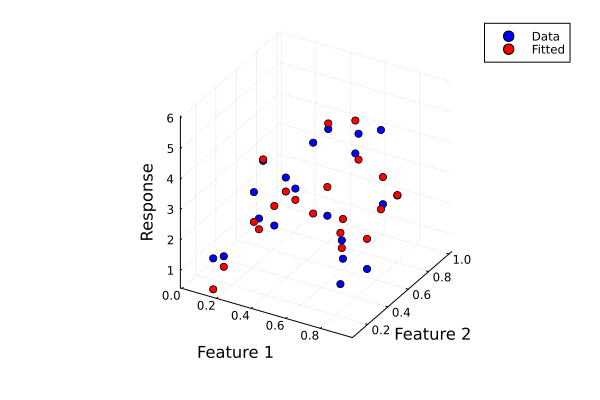

In [27]:
x = rand(20,2)
y = 2 .* x[:,1] .+ 3 .* x[:,2] .+ randn(20)

b = pinv(x' * x) * x' * y
yhat = x * b
scatter(x[:,1], x[:,2], y, label="Data", color=:blue, zlabel="Response")
scatter!(x[:,1], x[:,2], yhat, label="Fitted", color=:red)
xlabel!("Feature 1")
ylabel!("Feature 2")


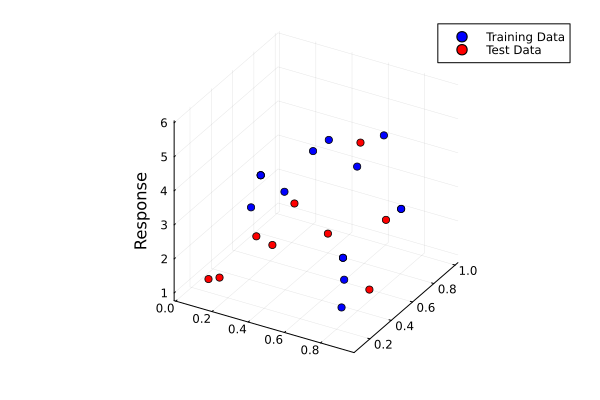

In [28]:
tr_ind = rand(1:20,15)
x_train = x[tr_ind, :]
y_train = y[tr_ind]
x_test = x[setdiff(1:20, tr_ind), :]
y_test = y[setdiff(1:20, tr_ind)]

scatter(x_train[:,1], x_train[:,2], y_train, label="Training Data", color=:blue, zlabel="Response")
scatter!(x_test[:,1], x_test[:,2], y_test, label="Test Data", color=:red, zlabel="Response")

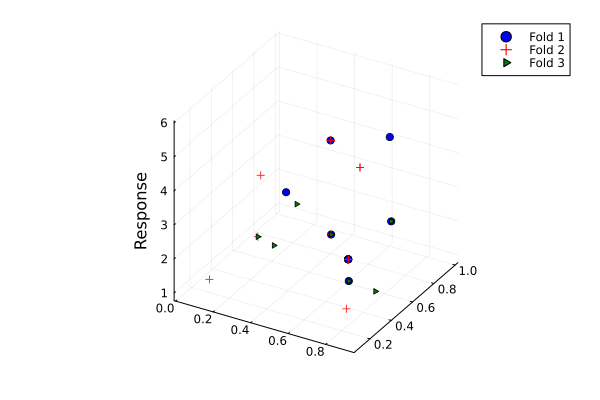

In [29]:
ind_cv = rand(1:20, 10,3)
x_cv1 = x[ind_cv[:,1], :]
y_cv1 = y[ind_cv[:,1]]
x_eval1 = x[setdiff(1:20, ind_cv[:,1]), :]
y_eval1 = y[setdiff(1:20, ind_cv[:,1])]

x_cv2 = x[ind_cv[:,2], :]
y_cv2 = y[ind_cv[:,2]]
x_eval2 = x[setdiff(1:20, ind_cv[:,2]), :]
y_eval2 = y[setdiff(1:20, ind_cv[:,2])]

x_cv3 = x[ind_cv[:,3], :]
y_cv3 = y[ind_cv[:,3]]
x_eval3 = x[setdiff(1:20, ind_cv[:,3]), :]
y_eval3 = y[setdiff(1:20, ind_cv[:,3])]

scatter(x_cv1[:,1], x_cv1[:,2], y_cv1, label="Fold 1", color=:blue, zlabel="Response")
scatter!(x_cv2[:,1], x_cv2[:,2], y_cv2, label="Fold 2", color=:red, zlabel="Response",marker=:cross)
scatter!(x_cv3[:,1], x_cv3[:,2], y_cv3, label="Fold 3", color=:green, zlabel="Response", marker=:>)

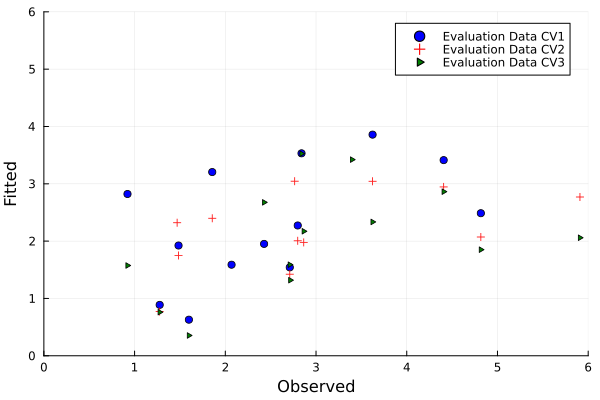

In [30]:
b_cv1 = pinv(x_cv1' * x_cv1) * x_cv1' * y_cv1
yhat_cv1 = x_eval1 * b_cv1

scatter(y_eval1, yhat_cv1, label="Evaluation Data CV1", color=:blue, zlabel="Response")

b_cv2 = pinv(x_cv2' * x_cv2) * x_cv2' * y_cv2
yhat_cv2 = x_eval2 * b_cv2

scatter!(y_eval2, yhat_cv2, label="Evaluation Data CV2", color=:red, zlabel="Response", marker=:cross)

b_cv3 = pinv(x_cv3' * x_cv3) * x_cv3' * y_cv3
yhat_cv3 = x_eval3 * b_cv3

scatter!(y_eval3, yhat_cv3, label="Evaluation Data CV3", color=:green, zlabel="Response", marker=:>)

xlabel!("Observed")
ylabel!("Fitted")
xlims!(0, 6)
ylims!(0, 6)


<div class="alert alert-block alert-warning">
<b>Tip:</b> As you can see the three generated models have a wide variety of uncertainty levels, indicating that your data is not homogeneously distributed. Therefore, certain care should be taken when selecting the train and test sets.  
</div>

## Extensive Exercise:

Import the Iris dataset and perform k-means clustering on that data. Use a combination of 5 fold CV and ROC curve to find the optimum number of k for the k-means.